<a href="https://colab.research.google.com/github/Sonuit22/ProjectSA/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import libraries

In [20]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [21]:
df = pd.read_csv("/content/Tweets.csv")
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


select columns

In [23]:
df= df[["airline_sentiment", "text"]]
df.columns = ["sentiment", "text"]
df.head()

,sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


In [24]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
  text = re.sub(r'\@\w+|\#', '', text)
  text = re.sub(r"[^a-zA-Z\s]", '', text)
  return text

df["clean_text"] = df["text"].apply(clean_text)
df.head()

,sentiment,text,clean_text
0,neutral,@VirginAmerica What @dhepburn said.,what said
1,positive,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experienc...
2,neutral,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take anothe...
3,negative,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious ente...
4,negative,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


label

In [25]:
label_map = {"negative":0, "positive":1}

df = df[df["sentiment"].isin(label_map.keys())]

df["label"] = df["sentiment"].map(label_map)

df["label"].value_counts()

,count
label,
0,9178
1,2363


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

TF-IDF

In [27]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

train model

In [28]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

evaluate

In [29]:
predictions = model.predict(X_test_vec)
print(accuracy_score(y_test, predictions))


0.9107838891294933




SECTION2: BERT MODEL
**bold text**

In [30]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

split again

In [31]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

Tokenizer

In [32]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [33]:
train_encodings = tokenizer(train_texts.tolist(), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts.tolist(), truncation=True, padding=True, max_length=128)

dataset

In [34]:
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels.tolist()
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": test_labels.tolist()
})

Model

In [35]:
bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Setup

In [36]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    learning_rate=2e-5
)

Metrics

In [37]:
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

Train, most time consuming along with TPU

In [38]:
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss
500,0.280458
1000,0.228715
1500,0.139708
2000,0.123731


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2308, training_loss=0.1830032090793656, metrics={'train_runtime': 269.1406, 'train_samples_per_second': 68.604, 'train_steps_per_second': 8.575, 'total_flos': 398514582224640.0, 'train_loss': 0.1830032090793656, 'epoch': 2.0})

## Evaluate
eval_accu=0.94

In [39]:
trainer.evaluate()

{'eval_loss': 0.2521311640739441,
 'eval_accuracy': 0.9462970983109571,
 'eval_runtime': 7.4391,
 'eval_samples_per_second': 310.387,
 'eval_steps_per_second': 38.849,
 'epoch': 2.0}

# SECTION3:**RoBERT**

Load RoBERT


In [40]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenize

In [41]:
train_encodings = roberta_tokenizer(train_texts.tolist(), truncation=True, padding=True, max_length=128)
test_encodings = roberta_tokenizer(test_texts.tolist(), truncation=True, padding=True, max_length=128)

Dataset

In [42]:
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels.tolist()
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": test_labels.tolist()
})

Train RoBERT

In [43]:
trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss
500,0.318830
1000,0.245150
1500,0.167130
2000,0.147825


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2308, training_loss=0.2076553893461178, metrics={'train_runtime': 333.8466, 'train_samples_per_second': 55.307, 'train_steps_per_second': 6.913, 'total_flos': 426979909526400.0, 'train_loss': 0.2076553893461178, 'epoch': 2.0})

**Confusion Matrix**

In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

predictions = trainer.predict(test_dataset)

import numpy as np
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels.values

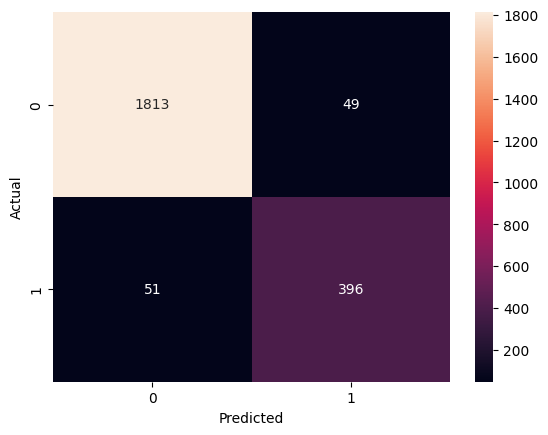

In [45]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1862
           1       0.89      0.89      0.89       447

    accuracy                           0.96      2309
   macro avg       0.93      0.93      0.93      2309
weighted avg       0.96      0.96      0.96      2309



In [47]:
!pip install wordcloud

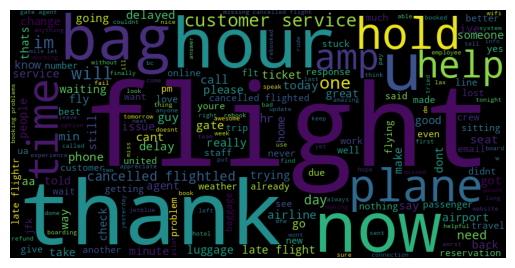

In [48]:
from wordcloud import WordCloud

text = " ".join(df["clean_text"])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()